# File for plots

Read data generated in `reinforcement_learning.ipynb`. Plot and compare. Save plots.

### Imports and settings

#### Imports

In [1]:
# Imports

# General
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm # used for progress bar
import json
import os

# Specials
from pyworld3 import World3
from pyworld3.utils import plot_world_variables, standard_setup
from rewards import *
from control_maps_and_loops import *

#### Settings

In [2]:
# Settings
SAVE_PLOTS = True

In [3]:
TRAIN_ID = "2"
RL_ID = "50"
CTRLWORLD_ID = "DCFSN"
CTRLWORLD_IDS = [CTRLWORLD_ID]
REWARD_NAME = "doughnut"

### Data extraction

#### Functions

In [4]:
def read_json(ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID):
    # ctrlworld_id: choose None to read from standard world instead of control world

    noise_status = None
    seed = -1
    ctrl_names = []
    grid_size = None
    threshold = None
    lookahead = None

    if ctrlworld_id==None:
        json_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_addinf_std.json"
    else:
        json_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_addinf_ctrlwrld{ctrlworld_id}.json"
    json_file = os.path.join(os.getcwd(), json_path)

    with open(json_file) as fjson:
        table = json.load(fjson)[0]
    
    noise_status = table["noise"]

    if noise_status:
        if ctrlworld_id==None:
            seed = table["seed_gen_std"]
        else:
            seed = table["seed_gen_ctrl"]

    if ctrlworld_id!=None:
        threshold = table["threshold"]
        lookahead = table["lookahead"]
        num_ctrls = table["num_ctrl_funcs"]
        ctrl1 = table["ctrl1"]
        grid_sz1 = table["grid_size_1"]
        ctrl_names.append(ctrl1)
        grid_size = [grid_sz1]
        if num_ctrls > 1:
            ctrl2 = table["ctrl2"]
            grid_sz2 = table["grid_size_2"]
            ctrl_names.append(ctrl2)
            grid_size.append(grid_sz2)

    return noise_status, seed, ctrl_names, grid_size, threshold, lookahead


def read_saved_parquet(control_names=[], ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID, expected_reward_cols=["J", "Jnorm", "nn", "nnnorm", "reward"], state_but_not_init_vars=["time"]):

    ctrl_vals = {}

    if ctrlworld_id!=None:
        parquet_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_control_world{ctrlworld_id}.parquet"
    else:
        parquet_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_standard_world.parquet"
    df = pd.read_parquet(parquet_path)

    col_names = df.columns # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html
    state_var_names = [col for col in col_names if (col not in expected_reward_cols)]
    init_state_var_names = [var for var in state_var_names if (var not in state_but_not_init_vars)]

    init_state_var_vals = df[init_state_var_names].to_numpy()[0]
    Js = df["J"].to_numpy()
    Js_norm = df["Jnorm"].to_numpy()
    nn_approx = df["nn"].to_numpy()
    nn_approx_norm = df["nnnorm"].to_numpy()
    reward = df["reward"].to_numpy()

    if ctrlworld_id!=None:
        for control_name in control_names:
            current_ctrl_vals = df[f"{control_name}_control"].to_numpy()
            ctrl_vals[control_name] = current_ctrl_vals
    
    times = df["time"].to_numpy()
    start_year = int(times[0])
    end_year = int(times[-1])

    return state_var_names, init_state_var_vals, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, start_year, end_year, times


def rebuild_world(start_year, end_year, noise_status, seed=-1, ctrl_names=[], ctrl_vals={}):
    # Returns: World3 object
    # NOTE: Currently we simply use standard setup for world (as this is what is done in reinforcement_learning.ipynb also) so changing the initial state variable values in the parquet file will not change the outcome of this function/World3 object

    world = World3(year_min=start_year, year_max=end_year, noise=noise_status, seed=seed)
    standard_setup(world)
    
    loop0(world)

    for k in range(1, world.n):
        for control_name in ctrl_names:
            value = ctrl_vals[control_name][k]
            set_control_to_constant(control_name, value, world)
        world._loopk_world3_fast(k-1, k, k-1, k)

    return world


def extract_data_from(ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID):
    # Returns: World3 object along with J, Jnorm, nn, nnnorm, reward and dictionary with control values for each control variable, and times
    # NOTE: Currently we simply use standard setup for world (as this is what is done in reinforcement_learning.ipynb also) so changing the initial state variable values in the parquet file will not change the outcome of this function/World3 object

    # Step 1: Get data from JSON file
    noise_status, seed, ctrl_names, grid_size, threshold, lookahead = read_json(ctrlworld_id, reward_name, train_id, rl_id)

    # Step 2: Get data from parquet file
    state_var_names, init_state_var_vals, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, start_year, end_year, times = read_saved_parquet(control_names=ctrl_names, ctrlworld_id=ctrlworld_id, reward_name=reward_name, train_id=train_id, rl_id=rl_id)

    # Step 3: Build world
    world = rebuild_world(start_year, end_year, noise_status, seed, ctrl_names, ctrl_vals)

    return world, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, times


def extract_and_add_from(reward_dict_of_dicts, world3_objects, control_values, ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID):
    # Returns World3 object and times, and stores information in existing dictionaries

    _, _, ctrl_names, _, _, _ = read_json(ctrlworld_id, reward_name, train_id, rl_id)

    world, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, times = extract_data_from(ctrlworld_id, reward_name, train_id, rl_id)

    if ctrlworld_id==None:
        id="std"
    else:
        id=ctrlworld_id
    
    world3_objects[id] = world

    reward_dict_of_dicts["J"][id] = Js
    reward_dict_of_dicts["Jnorm"][id] = Js_norm
    reward_dict_of_dicts["nn"][id] = nn_approx
    reward_dict_of_dicts["nnnorm"][id] = nn_approx_norm
    reward_dict_of_dicts["reward"][id] = reward
    
    for control_name in ctrl_names:
        control_values[id][control_name] = ctrl_vals[control_name]

    return world, times


def setup_reward_dictionaries(reward_types=["J", "Jnorm", "nn", "nnnorm", "reward"]):
    reward_dict_of_dicts = {}
    for reward_type in reward_types:
        reward_dict_of_dicts[reward_type] = {}
    return reward_dict_of_dicts


def setup_all_dictionaries(ctrlworld_ids=[]):

    reward_dict_of_dicts = setup_reward_dictionaries()

    world3_objects = {} # idea: key std used for standard world, control world ID used as key for control worlds

    control_values = {} # idea: dictionary of dictionaries, control world IDs used as keys in main dictionary, "sub-dictionaries" have keys for each control variable name
    for ctrlworld_id in ctrlworld_ids:
        control_values[ctrlworld_id] = {}

    return reward_dict_of_dicts, world3_objects, control_values


def main_data_extraction():
    return

#### Run functions

In [5]:
reward_dict_of_dicts, worlds, control_values = setup_all_dictionaries(ctrlworld_ids=CTRLWORLD_IDS)
world_reference, time = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=None)
for ctrlworld_id in CTRLWORLD_IDS:
    _, _ = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=ctrlworld_id)

### Plot

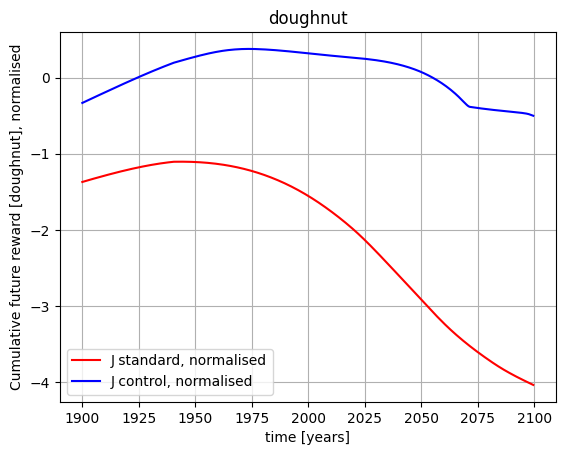

In [6]:
start = 0
end = -1

plt.plot(time[start:end], reward_dict_of_dicts["Jnorm"]["std"][start:end], 'r', label="J standard, normalised")
#plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"]["std"][start:end], 'r', label="nn on standard, normalised", linestyle='--')

for ctrlworld_id in CTRLWORLD_IDS:
    plt.plot(time[start:end], reward_dict_of_dicts["Jnorm"][ctrlworld_id][start:end], 'b', label="J control, normalised")
    #plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"][ctrlworld_id][start:end], 'b', label="nn on control, normalised", linestyle='--')




plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward [{REWARD_NAME}], normalised")
plt.title(f"{REWARD_NAME}")
plt.legend()
plt.grid()
plt.savefig(f"plots_clean/{REWARD_NAME}/J_norm_{ctrlworld_id}")
plt.show()



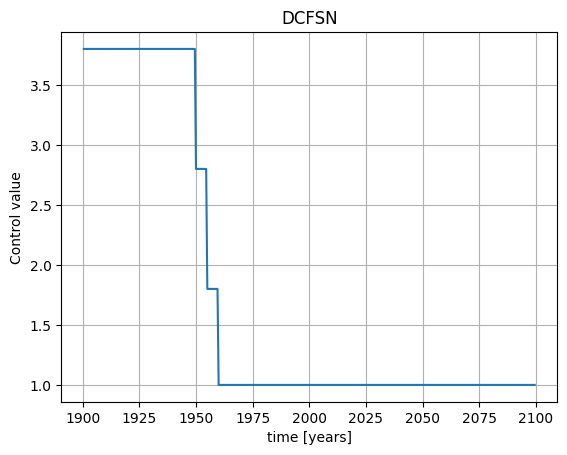

In [15]:
# Hur kommer jag åt värdena? 
# Hur lägger jag till vilken controlfunktion?

for ctrlworld_id in CTRLWORLD_IDS:
    plt.plot(time[start:end], control_values[ctrlworld_id]["DCFSN"][start:end])

plt.ylabel("Control value"), 
plt.xlabel("time [years]") 
plt.title(f"{ctrlworld_id}")
plt.grid()
plt.savefig(f"plots_clean/{REWARD_NAME}/controls_{ctrlworld_id}")
plt.show()

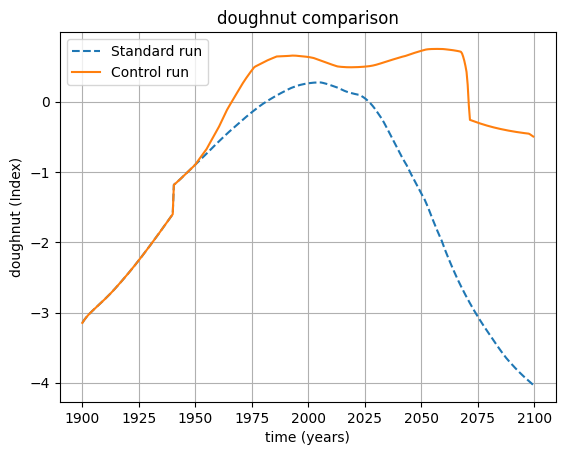

In [17]:

plt.plot(time[start:end], reward_dict_of_dicts["reward"]["std"][start:end], label="Standard run", linestyle='--')


for ctrlworld_id in CTRLWORLD_IDS:
    plt.plot(time[start:end], reward_dict_of_dicts["reward"][ctrlworld_id][start:end], label="Control run")


plt.xlabel("time (years)")
plt.legend()
plt.ylabel(f"{REWARD_NAME} (Index)")
plt.title(f"{REWARD_NAME} comparison")
plt.grid()
plt.savefig(f"plots_clean/{REWARD_NAME}/comparison_{ctrlworld_id}")
plt.show()



# ser konstig ut, typ mer inzoomad ocg de är inte identiska i början


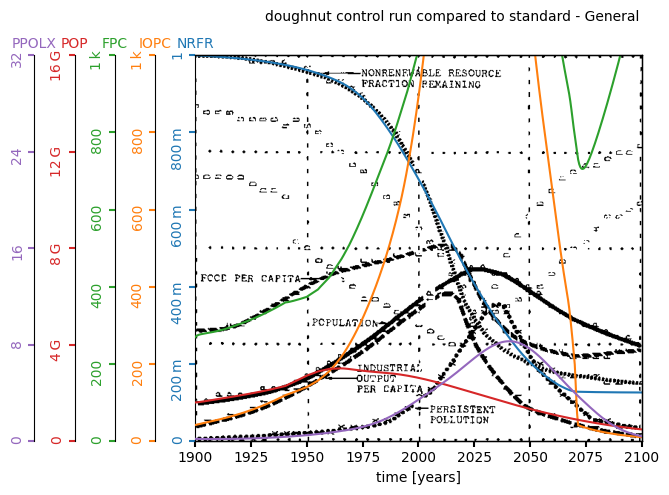

In [18]:


reward_name = REWARD_NAME
world_control = worlds[CTRLWORLD_ID]

plot_world_variables(
    world_control.time,
    [world_control.nrfr, world_control.iopc, world_control.fpc, world_control.pop, world_control.ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title=f"{reward_name} control run compared to standard - General",
)
plt.savefig(f"plots/{reward_name}/general")
plt.show()

### Test

In [ ]:
# test

reward_dict_of_dicts, worlds, control_values = setup_all_dictionaries(ctrlworld_ids=CTRLWORLD_IDS)
world_reference, time = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=None)
for ctrlworld_id in CTRLWORLD_IDS:
    _, _ = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=ctrlworld_id)

start = 0
end = -1

plt.plot(time[start:end], reward_dict_of_dicts["Jnorm"][CTRLWORLD_ID][start:end], 'b', label="J control, normalised")
plt.plot(time[start:end], reward_dict_of_dicts["Jnorm"]["std"][start:end], 'r', label="J standard, normalised")
plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward [{REWARD_NAME}], normalised")
plt.title(f"{REWARD_NAME}")
plt.legend()
plt.grid()
plt.show()